In [2]:
!pip install -q kaggle
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
!kaggle datasets download -d rashikrahmanpritom/plant-disease-recognition-dataset -p dataset --unzip

cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory
Dataset URL: https://www.kaggle.com/datasets/rashikrahmanpritom/plant-disease-recognition-dataset
License(s): CC0-1.0
100% 1.25G/1.25G [00:41<00:00, 32.6MB/s]



In [3]:
#Verify the data set
import zipfile
import os

zip_path = "dataset/plant-disease-recognition-dataset.zip"

if os.path.exists(zip_path):
    print("Extracting zip file...")
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall("dataset")
    print("Extraction done.")

# Check directory structure and image counts
base_dir = "dataset"
for split in ['Train', 'Validation', 'Test']:
    split_path = os.path.join(base_dir, split)
    if os.path.exists(split_path):
        print(f"\n--- {split} Split ---")
        for cls in ['Healthy', 'Powdery', 'Rust']:
            cls_path = os.path.join(split_path, cls)
            count = len(os.listdir(cls_path)) if os.path.exists(cls_path) else 0
            print(f"  {cls}: {count} images")
    else:
        print(f"\nPath not found: {split_path}")


--- Train Split ---
  Healthy: 0 images
  Powdery: 0 images
  Rust: 0 images

--- Validation Split ---
  Healthy: 0 images
  Powdery: 0 images
  Rust: 0 images

--- Test Split ---
  Healthy: 0 images
  Powdery: 0 images
  Rust: 0 images


In [4]:
import os

print("Top-level dataset folder contents:")
print(os.listdir("dataset"))

# Walk through the directory tree to find where the classes are located
for root, dirs, files in os.walk("dataset"):
    if len(files) > 0 and not root.endswith(".zip"):
        print(f"Found {len(files)} files in: {root}")

Top-level dataset folder contents:
['Train', 'Test', 'Validation']
Found 434 files in: dataset/Train/Train/Rust
Found 458 files in: dataset/Train/Train/Healthy
Found 430 files in: dataset/Train/Train/Powdery
Found 50 files in: dataset/Test/Test/Rust
Found 50 files in: dataset/Test/Test/Healthy
Found 50 files in: dataset/Test/Test/Powdery
Found 20 files in: dataset/Validation/Validation/Rust
Found 20 files in: dataset/Validation/Validation/Healthy
Found 20 files in: dataset/Validation/Validation/Powdery


Preprocessing the Images

In [5]:
import tensorflow as tf

IMAGE_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

# 1. Direct paths to the actual subdirectories
train_dir = "dataset/Train/Train"
val_dir = "dataset/Validation/Validation"
test_dir = "dataset/Test/Test"

# 2. Load Datasets
# Note: Test set has shuffle=False to preserve order for final evaluation matrices
train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical',
    shuffle=True,
    seed=SEED
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    val_dir,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical',
    shuffle=False
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical',
    shuffle=False
)

class_names = train_ds.class_names
print("Classes found:", class_names)

# 3. Augmentation Pipeline (Applied ONLY to Train to prevent data leakage)
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal_and_vertical", seed=SEED),
    tf.keras.layers.RandomRotation(0.1, seed=SEED),
    tf.keras.layers.RandomZoom(0.1, seed=SEED),
], name="data_augmentation")

# 4. Map ResNet50-specific preprocessing
def preprocess_train(images, labels):
    return tf.keras.applications.resnet50.preprocess_input(data_augmentation(images, training=True)), labels

def preprocess_val_test(images, labels):
    return tf.keras.applications.resnet50.preprocess_input(images), labels

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.map(preprocess_train, num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)
val_ds = val_ds.map(preprocess_val_test, num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)
test_ds = test_ds.map(preprocess_val_test, num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)

# Quick sanity check on a batch
for sample_images, sample_labels in train_ds.take(1):
    print("Batch images shape:", sample_images.shape)
    print("Batch labels shape:", sample_labels.shape)

Found 1322 files belonging to 3 classes.
Found 60 files belonging to 3 classes.
Found 150 files belonging to 3 classes.
Classes found: ['Healthy', 'Powdery', 'Rust']
Batch images shape: (32, 224, 224, 3)
Batch labels shape: (32, 3)


### **Build and Train the Frozen Baseline Model**
In this step, we keep the entire ResNet50 backbone frozen so that its pretrained ImageNet representations remain intact, and we train only a new classification head on top


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


Model: "ResNet50_Classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ avg_pool                        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ head_dropout (Dropout)          │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 3)              │         6,147 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,593,859 (90.00 MB)

 Trainable params: 6,147 (24.01 KB)

 Non-trainable params: 23,587,712 (89.98 MB)

Epoch 1/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 86s 2s/step - accuracy: 0.7579 - loss: 0.5898 - val_accuracy: 0.9500 - val_loss: 0.1709
Epoch 2/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 61s 1s/step - accuracy: 0.9334 - loss: 0.2158 - val_accuracy: 0.9500 - val_loss: 0.1166
Epoch 3/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 81s 1s/step - accuracy: 0.9622 - loss: 0.1591 - val_accuracy: 0.9833 - val_loss: 0.0855
Epoch 4/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 82s 1s/step - accuracy: 0.9592 - loss: 0.1462 - val_accuracy: 0.9833 - val_loss: 0.0682
Epoch 5/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 58s 1s/step - accuracy: 0.9773 - loss: 0.1088 - val_accuracy: 0.9833 - val_loss: 0.0769
Epoch 6/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 58s 1s/step - accuracy: 0.9766 - loss: 0.1013 - val_accuracy: 1.0000 - val_loss: 0.0388
Epoch 7/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 57s 1s/step - accuracy: 0.9758 - loss: 0.0855 - val_accuracy: 1.0000 - val_loss: 0.0383
Epoch 8/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 56s 1s/step - accuracy: 0.9796 - loss: 0.0863 - val_accuracy: 1.0000 - val_loss:

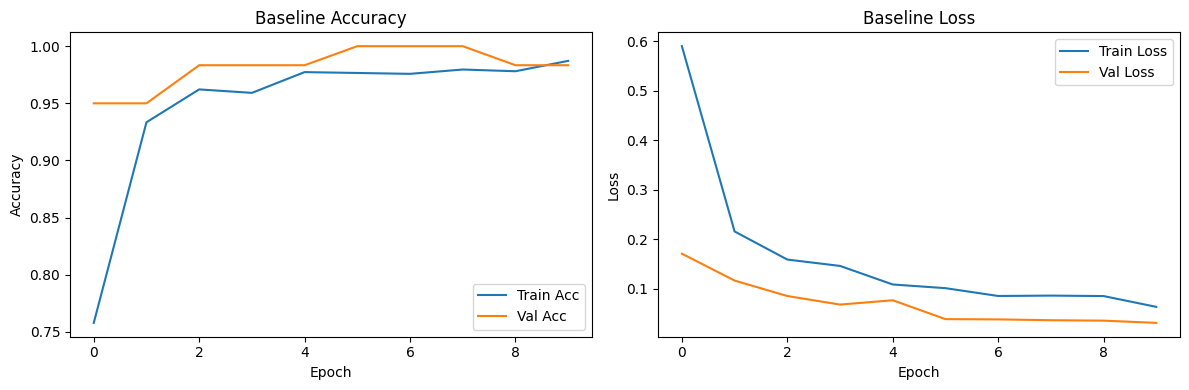

In [6]:
import time
import matplotlib.pyplot as plt

# 1. Base Model with ImageNet weights (backbone frozen)
base_model = tf.keras.applications.ResNet50(
    include_top=False,
    weights="imagenet",
    input_shape=(224, 224, 3)
)
base_model.trainable = False

# 2. Add Classification Head
inputs = tf.keras.Input(shape=(224, 224, 3))
x = base_model(inputs, training=False)  # keep BatchNormalization in inference mode
x = tf.keras.layers.GlobalAveragePooling2D(name="avg_pool")(x)
x = tf.keras.layers.Dropout(0.2, seed=SEED, name="head_dropout")(x)
outputs = tf.keras.layers.Dense(3, activation="softmax", name="predictions")(x)

model = tf.keras.Model(inputs=inputs, outputs=outputs, name="ResNet50_Classifier")

# 3. Compile Baseline Model (Learning rate 1e-3)
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

# 4. Train Baseline (10 Epochs)
EPOCHS_BASE = 10
start_time = time.time()

history_base = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_BASE
)

base_duration = round(time.time() - start_time, 2)
print(f"\nBaseline training finished in {base_duration} seconds.")

# 5. Plot & Save Baseline Learning Curves
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(history_base.history['accuracy'], label='Train Acc')
ax[0].plot(history_base.history['val_accuracy'], label='Val Acc')
ax[0].set_title('Baseline Accuracy')
ax[0].set_xlabel('Epoch')
ax[0].set_ylabel('Accuracy')
ax[0].legend()

ax[1].plot(history_base.history['loss'], label='Train Loss')
ax[1].plot(history_base.history['val_loss'], label='Val Loss')
ax[1].set_title('Baseline Loss')
ax[1].set_xlabel('Epoch')
ax[1].set_ylabel('Loss')
ax[1].legend()

plt.tight_layout()
plt.savefig('resnet50_baseline_curves.png')
plt.show()

### **Fine-Tune Upper ResNet50 Layers (RESNET50-FT-01)**
To satisfy the fine-tuning requirement, we unfreeze only the top residual block of ResNet50 (from conv5_block1_out to the top) while keeping earlier feature extractors frozen. We compile with a lower learning rate ($10^{-5}$) so we do not wreck the pretrained weights, and use EarlyStopping with restore_best_weights=True

Total Trainable Parameters for Fine-Tuning: 14,959,619
Epoch 1/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 81s 1s/step - accuracy: 0.9856 - loss: 0.0501 - val_accuracy: 1.0000 - val_loss: 0.0096
Epoch 2/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 56s 1s/step - accuracy: 0.9932 - loss: 0.0268 - val_accuracy: 1.0000 - val_loss: 0.0086
Epoch 3/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 85s 1s/step - accuracy: 0.9924 - loss: 0.0255 - val_accuracy: 0.9833 - val_loss: 0.0170
Epoch 4/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 58s 1s/step - accuracy: 0.9917 - loss: 0.0181 - val_accuracy: 1.0000 - val_loss: 0.0040
Epoch 5/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 82s 1s/step - accuracy: 0.9955 - loss: 0.0155 - val_accuracy: 0.9833 - val_loss: 0.0139
Epoch 6/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 85s 1s/step - accuracy: 0.9939 - loss: 0.0139 - val_accuracy: 1.0000 - val_loss: 0.0087
Epoch 7/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 59s 1s/step - accuracy: 0.9970 - loss: 0.0091 - val_accuracy: 0.9833 - val_loss: 0.0281
Epoch 7: early stopping
Restoring model weights from the end of

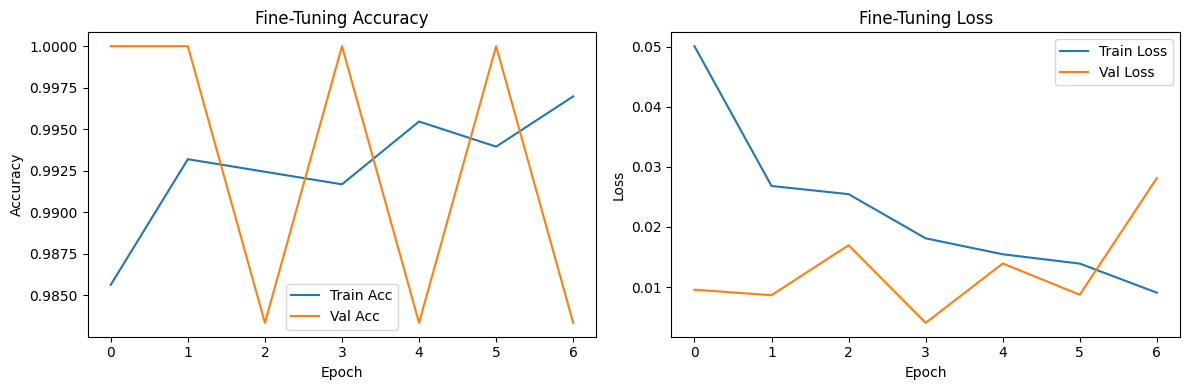

In [7]:
import numpy as np

# 1. Unfreeze base model
base_model.trainable = True

# 2. Freeze everything except the top residual block (stage 5)
fine_tune_at = "conv5_block1_1_conv"
trainable = False

for layer in base_model.layers:
    if layer.name == fine_tune_at:
        trainable = True
    layer.trainable = trainable
    # Keep BatchNormalization in inference mode to prevent destabilizing batch statistics
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False

trainable_count = sum(np.prod(p.shape) for p in model.trainable_weights)
print(f"Total Trainable Parameters for Fine-Tuning: {trainable_count:,}")

# 3. Re-compile with a lower learning rate
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

# 4. Callbacks: Early stopping based on validation loss
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=3,
        restore_best_weights=True,
        verbose=1
    )
]

# 5. Train Fine-Tuning Stage (Up to 10 additional epochs)
EPOCHS_FT = 10
start_ft_time = time.time()

history_ft = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_FT,
    callbacks=callbacks
)

ft_duration = round(time.time() - start_ft_time, 2)
print(f"\nFine-tuning finished in {ft_duration} seconds.")

# 6. Plot & Save Fine-Tuning Learning Curves
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(history_ft.history['accuracy'], label='Train Acc')
ax[0].plot(history_ft.history['val_accuracy'], label='Val Acc')
ax[0].set_title('Fine-Tuning Accuracy')
ax[0].set_xlabel('Epoch')
ax[0].set_ylabel('Accuracy')
ax[0].legend()

ax[1].plot(history_ft.history['loss'], label='Train Loss')
ax[1].plot(history_ft.history['val_loss'], label='Val Loss')
ax[1].set_title('Fine-Tuning Loss')
ax[1].set_xlabel('Epoch')
ax[1].set_ylabel('Loss')
ax[1].legend()

plt.tight_layout()
plt.savefig('resnet50_finetuning_curves.png')
plt.show()

### **Final Test Evaluation & Error Analysis**
Now, we evaluate the finalized model on the untouched test split (150 images). We will compute


1.   Classification report (Precision, Recall, F1 per class and weighted)
2.   Multi-class ROC-AUC

1.   Confusion matrix
2.   Identification and logging of any misclassified test samples





--- Test Set Performance ---
Test Accuracy: 98.00%
ROC-AUC (OVR, Weighted): 0.9988

              precision    recall  f1-score   support

     Healthy     0.9608    0.9800    0.9703        50
     Powdery     1.0000    0.9600    0.9796        50
        Rust     0.9804    1.0000    0.9901        50

    accuracy                         0.9800       150
   macro avg     0.9804    0.9800    0.9800       150
weighted avg     0.9804    0.9800    0.9800       150



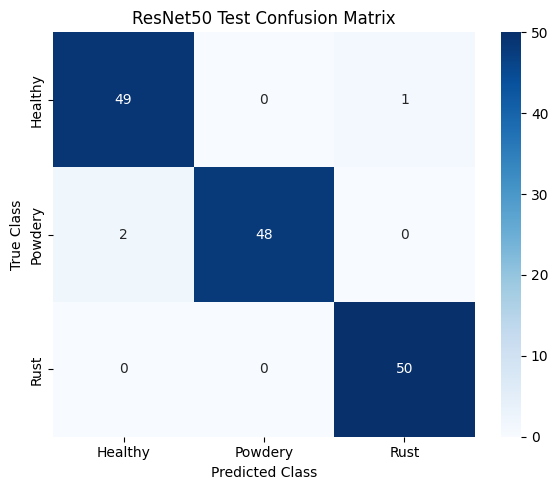

Total Misclassified Test Samples: 3


,sample_index,true_class,predicted_class,confidence,healthy_prob,powdery_prob,rust_prob
0,22,Healthy,Rust,0.955992,0.043983,0.000025,0.955992
1,55,Powdery,Healthy,0.808868,0.808868,0.025392,0.165739
2,61,Powdery,Healthy,0.900114,0.900114,0.029283,0.070603


In [8]:
import numpy as np
import pandas as pd
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import seaborn as sns

# 1. Collect true labels and predictions on the test dataset
y_true_list = []
y_pred_probs_list = []

for images, labels in test_ds:
    probs = model.predict(images, verbose=0)
    y_true_list.append(labels.numpy())
    y_pred_probs_list.append(probs)

y_true_onehot = np.vstack(y_true_list)
y_pred_probs = np.vstack(y_pred_probs_list)

y_true = np.argmax(y_true_onehot, axis=1)
y_pred = np.argmax(y_pred_probs, axis=1)

# 2. Compute Core Evaluation Metrics
test_acc = (y_true == y_pred).mean()
roc_auc = roc_auc_score(y_true_onehot, y_pred_probs, multi_class='ovr', average='weighted')

print(f"--- Test Set Performance ---")
print(f"Test Accuracy: {test_acc * 100:.2f}%")
print(f"ROC-AUC (OVR, Weighted): {roc_auc:.4f}\n")

report_dict = classification_report(y_true, y_pred, target_names=class_names, output_dict=True)
report_df = pd.DataFrame(report_dict).transpose()
print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

# 3. Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
cm_df = pd.DataFrame(cm, index=class_names, columns=class_names)
cm_df.to_csv("resnet50_confusion_matrix.csv")

plt.figure(figsize=(6, 5))
sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues')
plt.title("ResNet50 Test Confusion Matrix")
plt.ylabel("True Class")
plt.xlabel("Predicted Class")
plt.tight_layout()
plt.savefig("resnet50_confusion_matrix.png")
plt.show()

# 4. Error Analysis
misclassified_indices = np.where(y_true != y_pred)[0]
print(f"Total Misclassified Test Samples: {len(misclassified_indices)}")

error_records = []
for idx in misclassified_indices:
    error_records.append({
        "sample_index": idx,
        "true_class": class_names[y_true[idx]],
        "predicted_class": class_names[y_pred[idx]],
        "confidence": float(y_pred_probs[idx][y_pred[idx]]),
        "healthy_prob": float(y_pred_probs[idx][0]),
        "powdery_prob": float(y_pred_probs[idx][1]),
        "rust_prob": float(y_pred_probs[idx][2])
    })

error_df = pd.DataFrame(error_records)
error_df.to_csv("resnet50_error_analysis.csv", index=False)
if not error_df.empty:
    display(error_df)
else:
    print("Zero errors on the test set.")

In [9]:
import json
import os
import matplotlib.pyplot as plt
import pandas as pd

# 1. Create target directories
os.makedirs("models", exist_ok=True)
os.makedirs("results", exist_ok=True)

# 2. Save the trained model
model.save("models/resnet50_leaf_model.keras")
print("Saved model to models/resnet50_leaf_model.keras")

# 3. Save Preprocessing & Model Config
config = {
    "model_name": "ResNet50",
    "image_size": [224, 224],
    "batch_size": 32,
    "seed": 42,
    "classes": class_names,
    "preprocessing": "tf.keras.applications.resnet50.preprocess_input",
    "augmentation": ["RandomFlip(horizontal_and_vertical)", "RandomRotation(0.1)", "RandomZoom(0.1)"],
    "baseline_epochs": 10,
    "baseline_lr": 1e-3,
    "finetune_layers": "Stage 5 (conv5_block1_1_conv upward)",
    "finetune_lr": 1e-5,
    "early_stopping_patience": 3,
    "best_epoch": 4
}

with open("results/resnet50_preprocessing_config.json", "w") as f:
    json.dump(config, f, indent=4)

# 4. Save Final Test Results CSV
final_results = [{
    "model": "ResNet50",
    "test_accuracy": float(test_acc),
    "weighted_precision": float(report_dict["weighted avg"]["precision"]),
    "weighted_recall": float(report_dict["weighted avg"]["recall"]),
    "weighted_f1": float(report_dict["weighted avg"]["f1-score"]),
    "roc_auc_weighted": float(roc_auc),
    "healthy_f1": float(report_dict["Healthy"]["f1-score"]),
    "powdery_f1": float(report_dict["Powdery"]["f1-score"]),
    "rust_f1": float(report_dict["Rust"]["f1-score"]),
    "total_params": 23593859,
    "finetune_trainable_params": 14959619,
    "baseline_time_sec": 657.52,
    "finetune_time_sec": 505.58,
    "total_training_time_sec": 1163.10
}]
pd.DataFrame(final_results).to_csv("results/resnet50_final_results.csv", index=False)

# 5. Save Experiment Comparison (Baseline vs Fine-Tuned)
experiments = [
    {
        "experiment_id": "RESNET50-BASE-01",
        "description": "Frozen ResNet50 backbone + Classification Head",
        "trainable_params": 6147,
        "learning_rate": 0.001,
        "epochs_trained": 10,
        "best_epoch": 10,
        "val_loss": 0.0312,
        "val_accuracy": 0.9833,
        "train_time_sec": 657.52
    },
    {
        "experiment_id": "RESNET50-FT-01",
        "description": "Fine-tuned Stage 5 residual block with EarlyStopping",
        "trainable_params": 14959619,
        "learning_rate": 0.00001,
        "epochs_trained": 7,
        "best_epoch": 4,
        "val_loss": 0.0040,
        "val_accuracy": 1.0000,
        "train_time_sec": 505.58
    }
]
pd.DataFrame(experiments).to_csv("results/resnet50_experiment_comparison.csv", index=False)

# 6. Save individual plot images to match repository structure
# Baseline Accuracy
plt.figure()
plt.plot(history_base.history['accuracy'], label='Train Accuracy')
plt.plot(history_base.history['val_accuracy'], label='Val Accuracy')
plt.title('ResNet50 Baseline Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.tight_layout()
plt.savefig('results/resnet50_baseline_accuracy.png')
plt.close()

# Baseline Loss
plt.figure()
plt.plot(history_base.history['loss'], label='Train Loss')
plt.plot(history_base.history['val_loss'], label='Val Loss')
plt.title('ResNet50 Baseline Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()
plt.savefig('results/resnet50_baseline_loss.png')
plt.close()

# Fine-tuning Accuracy
plt.figure()
plt.plot(history_ft.history['accuracy'], label='Train Accuracy')
plt.plot(history_ft.history['val_accuracy'], label='Val Accuracy')
plt.title('ResNet50 Fine-Tuning Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.tight_layout()
plt.savefig('results/resnet50_finetuning_accuracy.png')
plt.close()

# Fine-tuning Loss
plt.figure()
plt.plot(history_ft.history['loss'], label='Train Loss')
plt.plot(history_ft.history['val_loss'], label='Val Loss')
plt.title('ResNet50 Fine-Tuning Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()
plt.savefig('results/resnet50_finetuning_loss.png')
plt.close()

# Move CSV outputs to results/
!mv resnet50_confusion_matrix.csv results/
!mv resnet50_error_analysis.csv results/
!mv resnet50_confusion_matrix.png results/

# 7. Zip all generated artifacts for single-click download
!zip -r resnet50_artifacts.zip models/ results/

print("\nAll artifacts generated and packaged into resnet50_artifacts.zip successfully!")

Saved model to models/resnet50_leaf_model.keras
  adding: models/ (stored 0%)
  adding: models/resnet50_leaf_model.keras (deflated 7%)
  adding: results/ (stored 0%)
  adding: results/resnet50_error_analysis.csv (deflated 44%)
  adding: results/resnet50_final_results.csv (deflated 43%)
  adding: results/resnet50_baseline_loss.png (deflated 9%)
  adding: results/resnet50_experiment_comparison.csv (deflated 25%)
  adding: results/resnet50_finetuning_loss.png (deflated 7%)
  adding: results/resnet50_preprocessing_config.json (deflated 49%)
  adding: results/resnet50_baseline_accuracy.png (deflated 10%)
  adding: results/resnet50_confusion_matrix.png (deflated 13%)
  adding: results/resnet50_finetuning_accuracy.png (deflated 6%)
  adding: results/resnet50_confusion_matrix.csv (deflated 22%)

All artifacts generated and packaged into resnet50_artifacts.zip successfully!
